IMPORT LIBRARIES

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt 

dataset=pd.read_csv('Unemployment in India.csv')
dataset.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [5]:
dataset.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [46]:
dataset = dataset.dropna()
dataset.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [45]:
dataset['Date'] = pd.to_datetime(dataset['Date'], dayfirst=True)
dataset.info

<bound method DataFrame.info of              Region       Date Frequency  Estimated Unemployment Rate (%)  \
0    Andhra Pradesh 2019-05-31   Monthly                             3.65   
1    Andhra Pradesh 2019-06-30   Monthly                             3.05   
2    Andhra Pradesh 2019-07-31   Monthly                             3.75   
3    Andhra Pradesh 2019-08-31   Monthly                             3.32   
4    Andhra Pradesh 2019-09-30   Monthly                             5.17   
..              ...        ...       ...                              ...   
749     West Bengal 2020-02-29   Monthly                             7.55   
750     West Bengal 2020-03-31   Monthly                             6.67   
751     West Bengal 2020-04-30   Monthly                            15.63   
752     West Bengal 2020-05-31   Monthly                            15.22   
753     West Bengal 2020-06-30   Monthly                             9.86   

     Estimated Employed  Estimated Labour P

In [16]:
dataset.columns=dataset.columns.str.strip()
dataset.columns



Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [17]:
dataset.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [6]:
dataset['Region'].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str

In [7]:
dataset['Area'].unique()

<StringArray>
['Rural', 'Urban']
Length: 2, dtype: str

In [8]:
dataset['Area'].value_counts()

Area
Urban    381
Rural    359
Name: count, dtype: int64

In [15]:
dataset.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [18]:
dataset.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

Region
Andhra Pradesh       7.477143
Assam                6.428077
Bihar               18.918214
Chandigarh          15.991667
Chhattisgarh         9.240357
Delhi               16.495357
Goa                  9.274167
Gujarat              6.663929
Haryana             26.283214
Himachal Pradesh    18.540357
Jammu & Kashmir     16.188571
Jharkhand           20.585000
Karnataka            6.676071
Kerala              10.123929
Madhya Pradesh       7.406429
Maharashtra          7.557500
Meghalaya            4.798889
Odisha               5.657857
Puducherry          10.215000
Punjab              12.031071
Rajasthan           14.058214
Sikkim               7.249412
Tamil Nadu           9.284286
Telangana            7.737857
Tripura             28.350357
Uttar Pradesh       12.551429
Uttarakhand          6.582963
West Bengal          8.124643
Name: Estimated Unemployment Rate (%), dtype: float64

In [20]:
dataset.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

Date
29-02-2020     9.964717
30-04-2020    23.641569
30-06-2019     9.303333
30-06-2020    11.903600
30-09-2019     9.051731
30-11-2019     9.868364
31-01-2020     9.950755
31-03-2020    10.700577
31-05-2019     8.874259
31-05-2020    24.875294
31-07-2019     9.033889
31-08-2019     9.637925
31-10-2019     9.900909
31-12-2019     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

In [27]:
dataw=dataset[dataset['Region'].isin(['Assam','West Bengal','Uttarakhand'])]

<Axes: xlabel='Date', ylabel='Estimated Unemployment Rate (%)'>

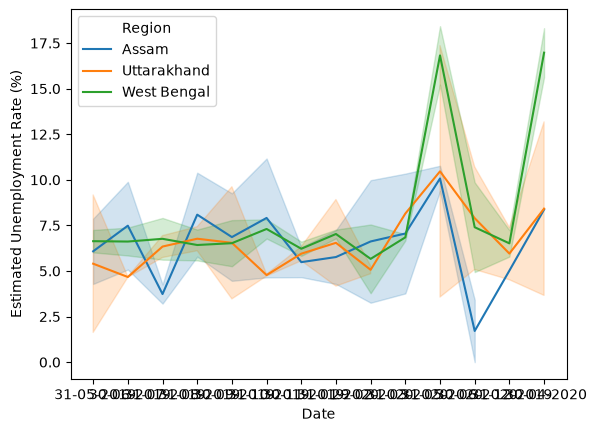

In [28]:
sns.lineplot(x='Date',y='Estimated Unemployment Rate (%)',hue='Region',data=dataw)

In [32]:
top10=dataset.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Tripura'),
  Text(1, 0, 'Haryana'),
  Text(2, 0, 'Jharkhand'),
  Text(3, 0, 'Bihar'),
  Text(4, 0, 'Himachal Pradesh'),
  Text(5, 0, 'Delhi'),
  Text(6, 0, 'Jammu & Kashmir'),
  Text(7, 0, 'Chandigarh'),
  Text(8, 0, 'Rajasthan'),
  Text(9, 0, 'Uttar Pradesh')])

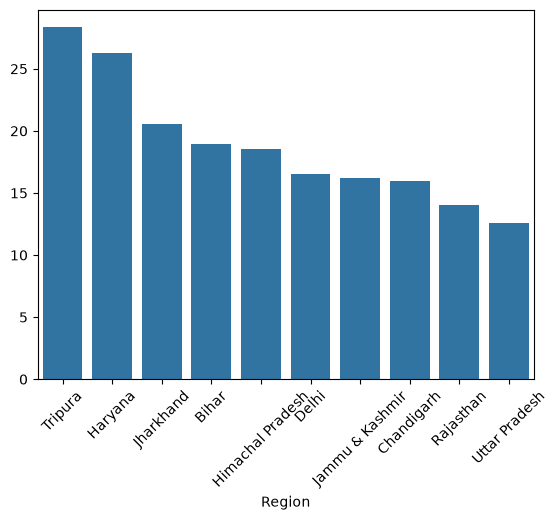

In [34]:
sns.barplot(x=top10.index,y=top10.values)
plt.xticks(rotation=45)

### Observations: Top 10 States by Average Unemployment Rate

Tripura (28.4%) and Haryana (26.3%) have by far the highest average unemployment 
rates in the dataset, more than double the rate seen in Uttar Pradesh (12.6%), 
which is the lowest among this top-10 group. Jharkhand, Bihar, and Himachal Pradesh 
round out the top five, all above 18%. Several of these states (Bihar, Jharkhand, 
Uttar Pradesh) are traditionally more agrarian/rural economies, which may make them 
more vulnerable to seasonal and pandemic-driven job disruptions. Jammu & Kashmir's 
presence in the top 10 (16.2%) may also reflect region-specific economic and 
security-related disruptions beyond just COVID-19.

In [38]:
corr=dataset[['Estimated Unemployment Rate (%)','Estimated Employed','Estimated Labour Participation Rate (%)']].corr()

<Axes: >

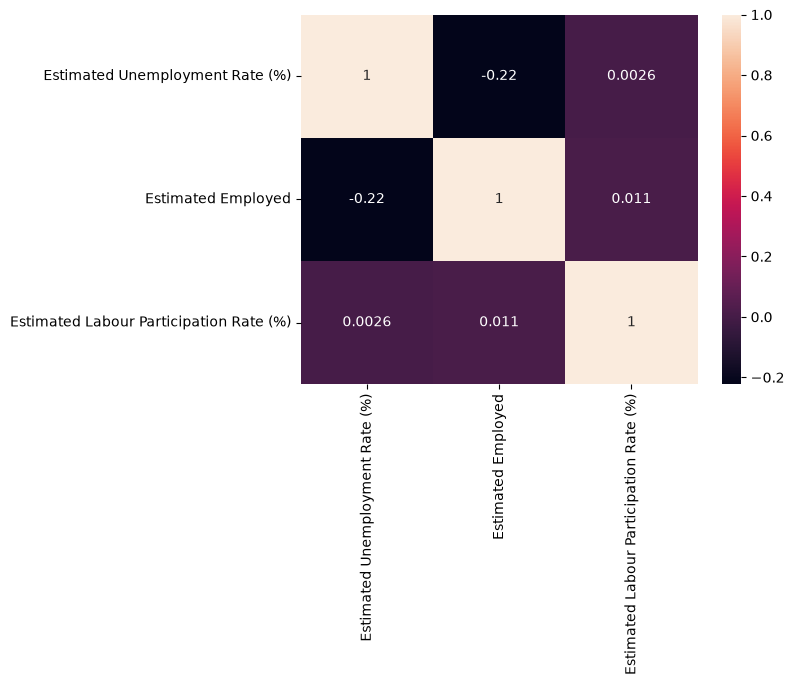

In [40]:
sns.heatmap(corr, annot=True)

Pre-COVID vs. post-COVID comparison

In [48]:
dataset[dataset['Date'] < '2020-03-01']

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
745,West Bengal,2019-10-31,Monthly,7.83,10563686.0,43.25,Urban
746,West Bengal,2019-11-30,Monthly,6.61,10768462.0,43.44,Urban
747,West Bengal,2019-12-31,Monthly,7.24,11335696.0,45.97,Urban
748,West Bengal,2020-01-31,Monthly,7.27,11208617.0,45.39,Urban


In [49]:
dataset[dataset['Date'] > '2020-03-01']

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
10,Andhra Pradesh,2020-03-31,Monthly,4.06,11359660.0,40.66,Rural
11,Andhra Pradesh,2020-04-30,Monthly,16.29,8792827.0,36.03,Rural
12,Andhra Pradesh,2020-05-31,Monthly,14.46,9526902.0,38.16,Rural
13,Andhra Pradesh,2020-06-30,Monthly,0.85,15572975.0,53.76,Rural
23,Assam,2020-03-31,Monthly,3.77,9878742.0,47.05,Rural
...,...,...,...,...,...,...,...
739,Uttarakhand,2020-06-30,Monthly,5.08,989470.0,35.61,Urban
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban


In [51]:
pre_covid = dataset[dataset['Date'] < '2020-03-01']['Estimated Unemployment Rate (%)'].mean()
post_covid = dataset[dataset['Date'] >= '2020-03-01']['Estimated Unemployment Rate (%)'].mean()

In [52]:
print("Pre-COVID average unemployment rate:", pre_covid)
print("Post-COVID average unemployment rate:", post_covid)

Pre-COVID average unemployment rate: 9.509533582089553
Post-COVID average unemployment rate: 17.774362745098042


### Observations: Pre-COVID vs. Post-COVID Unemployment

The average unemployment rate in India nearly doubled after the onset of COVID-19, 
rising from 9.51% (pre-March 2020) to 17.77% (March 2020 onward). This aligns with 
the sharp spikes seen earlier in the April–May 2020 monthly trend, confirming that 
the nationwide lockdown had a severe and immediate impact on employment across 
regions. While the post-COVID period does include some recovery months, the overall 
average remains substantially elevated compared to the pre-pandemic baseline.